# Task 1: Exploratory Data Analysis (EDA)

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [54]:
df.shape

(768, 9)

In [55]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [56]:
# Summary Statistics
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [57]:
#Missing Values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [58]:
#Duplicate values
df.duplicated().sum()

np.int64(0)

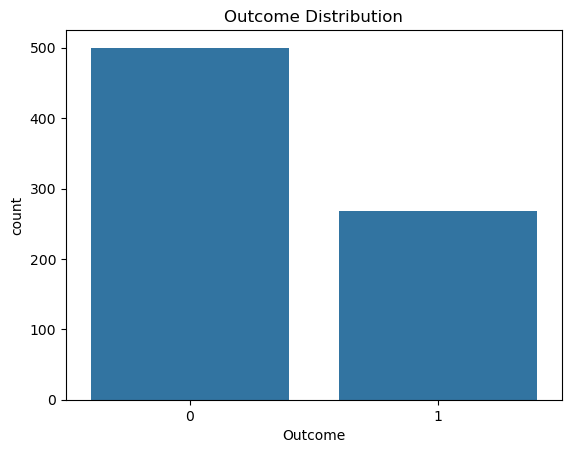

In [59]:
#Target Variable Distribution
sns.countplot(x='Outcome', data=df)
plt.title("Outcome Distribution")
plt.show()

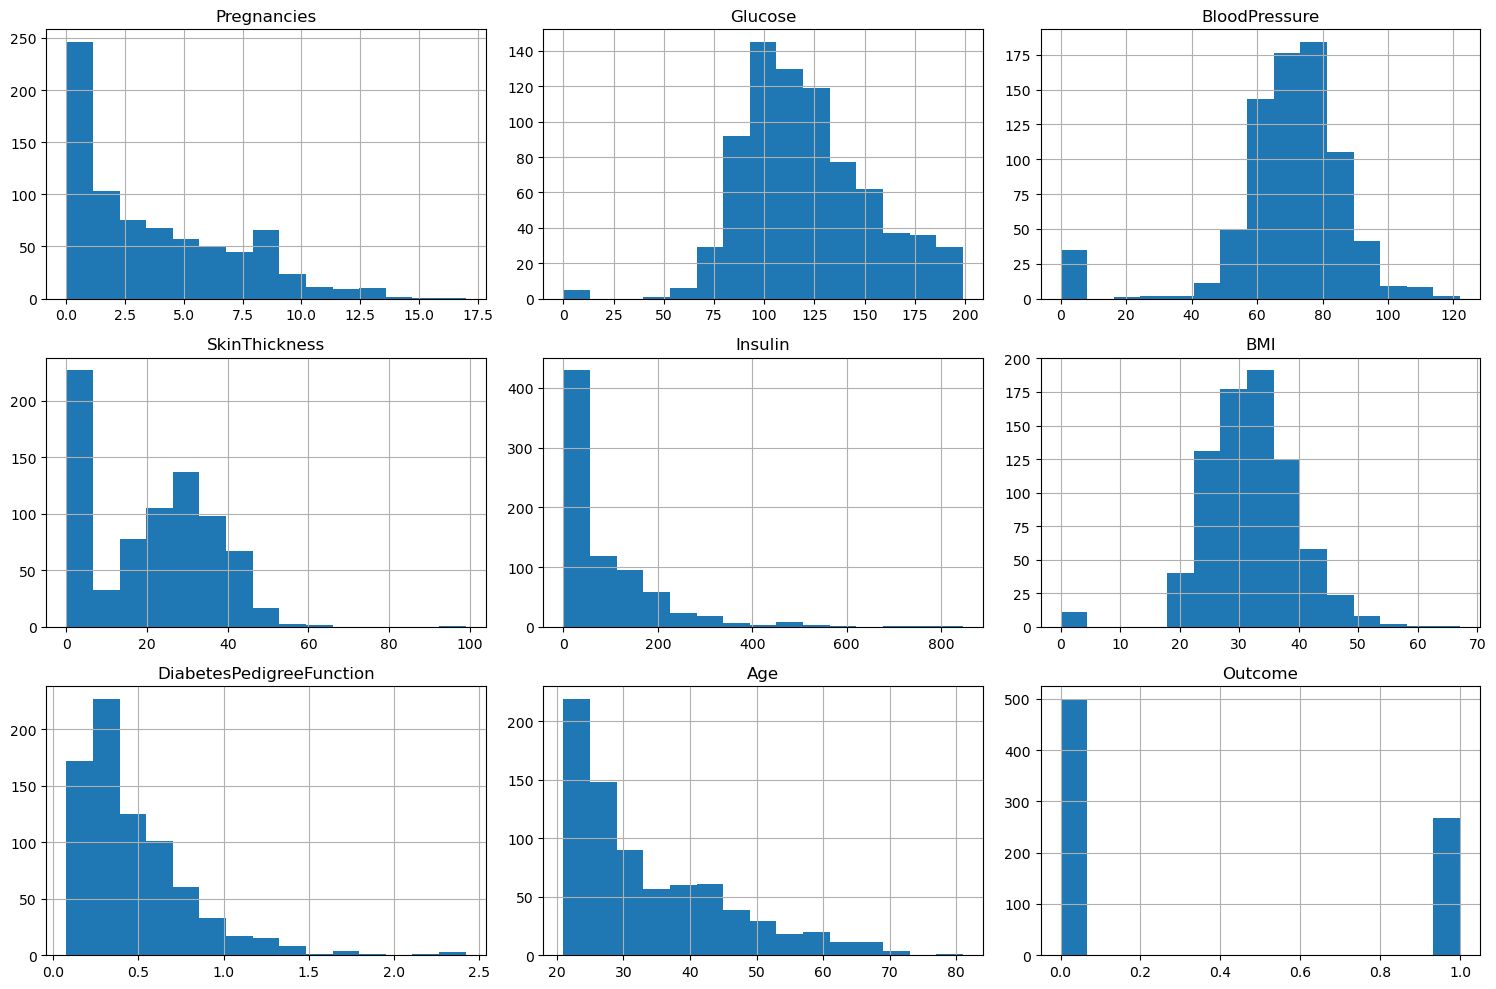

In [60]:
#Data Visualization
#Histograms
df.hist(figsize=(15,10), bins=15)

plt.tight_layout()
plt.show()

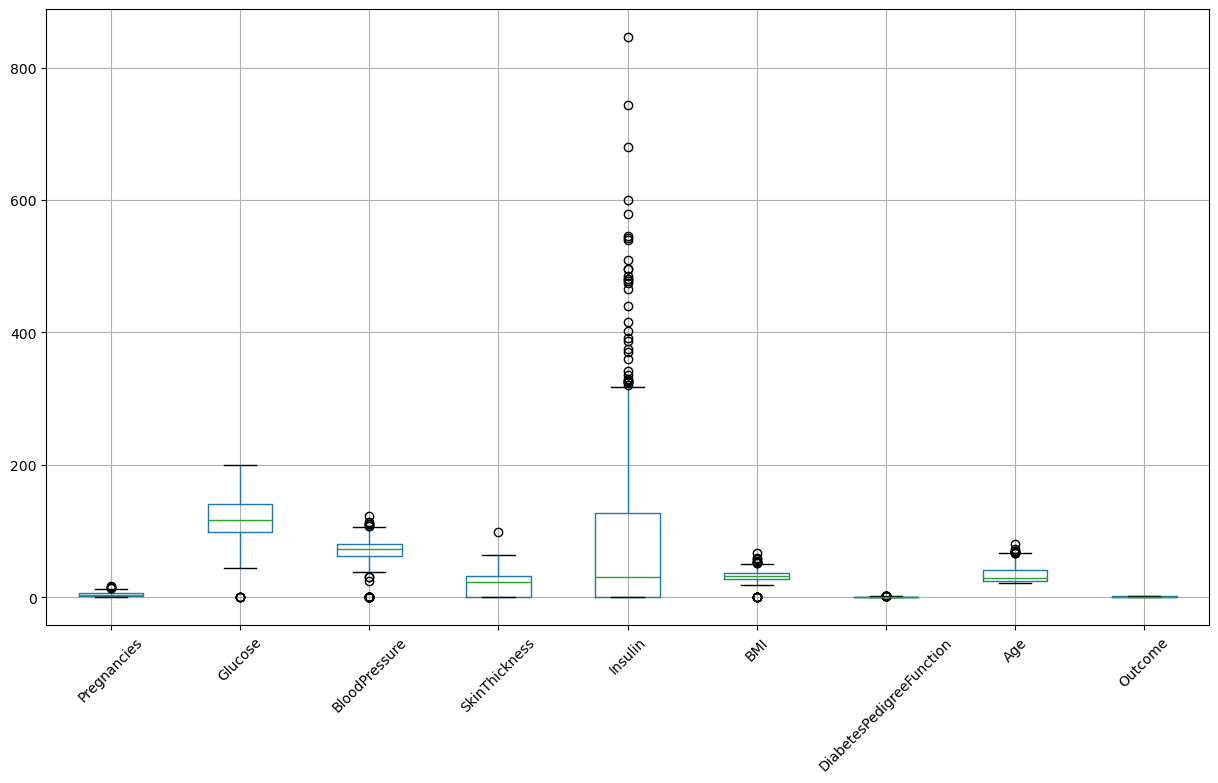

In [61]:
#Box Plots
plt.figure(figsize=(15,8))

df.boxplot()

plt.xticks(rotation=45)
plt.show()

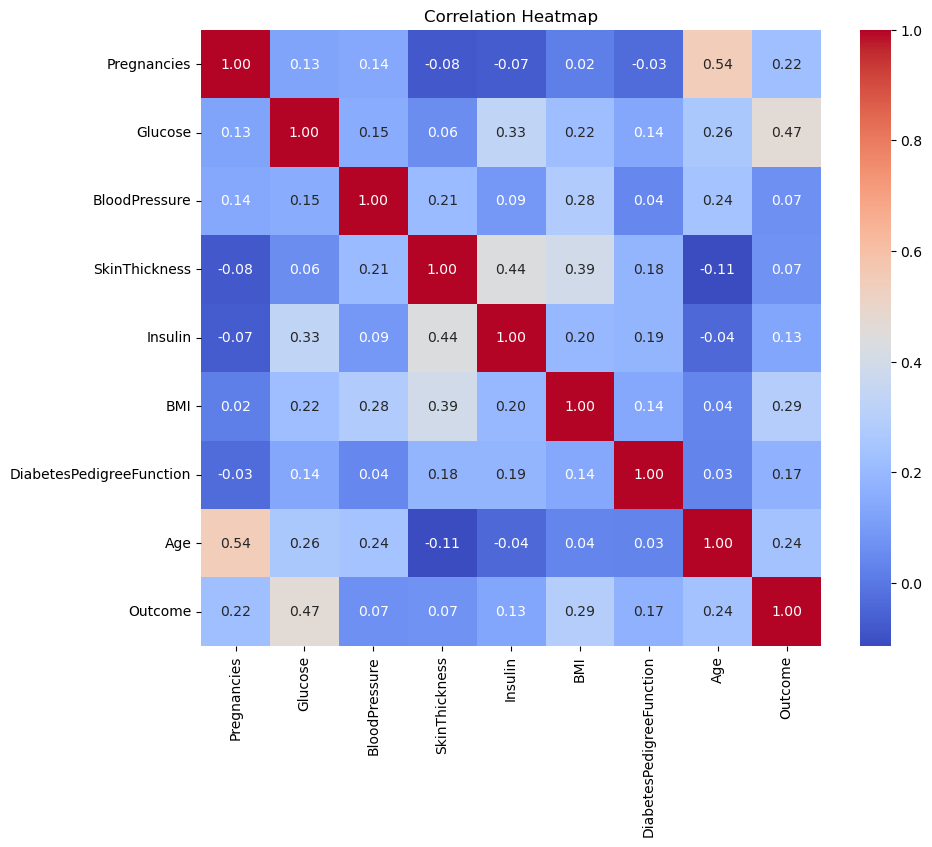

In [62]:
#Correlation Heatmaps
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

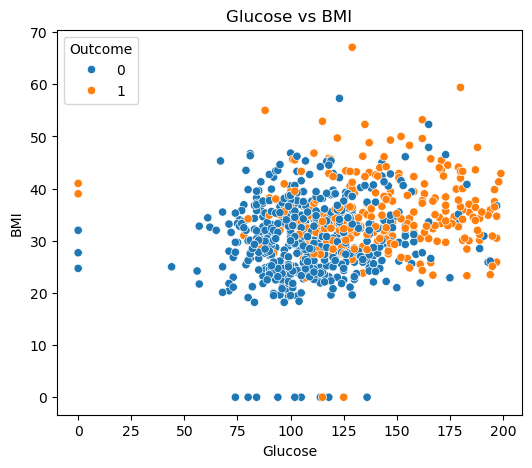

In [63]:
#ScatterPlot
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df,
    x='Glucose',
    y='BMI',
    hue='Outcome'
)

plt.title("Glucose vs BMI")
plt.show()

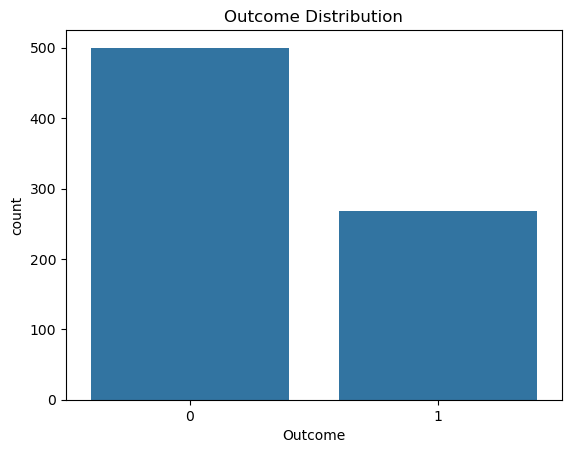

In [64]:
#BarPlot
sns.countplot(
    x='Outcome',
    data=df
)

plt.title("Outcome Distribution")
plt.show()

# Task 3: Data Preprocessing

In [65]:
#Checking Missing Values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [66]:
#No missing values were found in the dataset, so no imputation was required.

In [67]:
#Checking Data Types
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [68]:
#All features are numerical; therefore, no encoding techniques are required.

In [69]:
# Separating Features and Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [70]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,)

# Task 4: Building Predictive Models (XGBoost & LightGBM)

In [71]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

In [72]:
#XGBoost Model Building
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [73]:
# XGBoost Prediction
yhat_train_xgb = xgb_model.predict(X_train)
yhat_test_xgb = xgb_model.predict(X_test)

In [74]:
#Evaluation Function
def eval_clf(y, yhat):

    cm = confusion_matrix(y, yhat)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(y, yhat))

    print("Accuracy :", accuracy_score(y, yhat))
    print("Precision:", precision_score(y, yhat))
    print("Recall   :", recall_score(y, yhat))
    print("F1 Score :", f1_score(y, yhat))

Training Performance


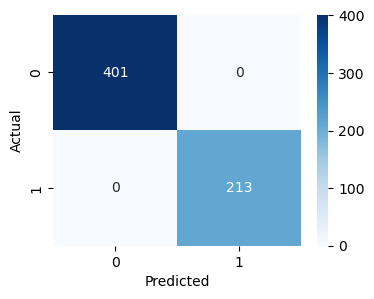

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       401
           1       1.00      1.00      1.00       213

    accuracy                           1.00       614
   macro avg       1.00      1.00      1.00       614
weighted avg       1.00      1.00      1.00       614

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Testing Performance


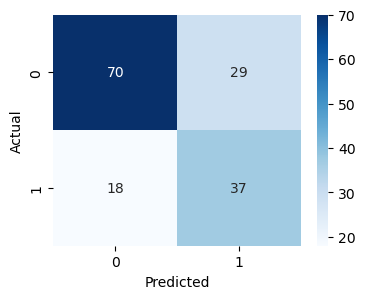

              precision    recall  f1-score   support

           0       0.80      0.71      0.75        99
           1       0.56      0.67      0.61        55

    accuracy                           0.69       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.71      0.69      0.70       154

Accuracy : 0.6948051948051948
Precision: 0.5606060606060606
Recall   : 0.6727272727272727
F1 Score : 0.6115702479338843


In [75]:
# XGBoost Evaluation
print("Training Performance")
eval_clf(y_train, yhat_train_xgb)

print("\nTesting Performance")
eval_clf(y_test, yhat_test_xgb)

# LightGBM

In [76]:
#Build Model
lgbm_model = LGBMClassifier(
    random_state=42
)

lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000796 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [77]:
# Prediction
yhat_train_lgb = lgbm_model.predict(X_train)
yhat_test_lgb = lgbm_model.predict(X_test)

Training Performance


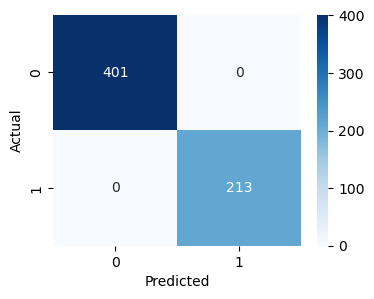

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       401
           1       1.00      1.00      1.00       213

    accuracy                           1.00       614
   macro avg       1.00      1.00      1.00       614
weighted avg       1.00      1.00      1.00       614

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Testing Performance


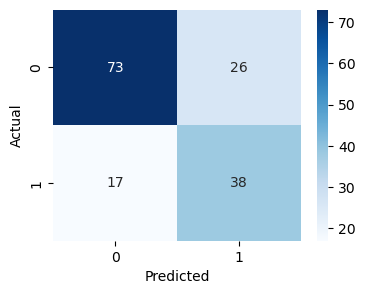

              precision    recall  f1-score   support

           0       0.81      0.74      0.77        99
           1       0.59      0.69      0.64        55

    accuracy                           0.72       154
   macro avg       0.70      0.71      0.71       154
weighted avg       0.73      0.72      0.72       154

Accuracy : 0.7207792207792207
Precision: 0.59375
Recall   : 0.6909090909090909
F1 Score : 0.6386554621848739


In [78]:
# Evaluation
print("Training Performance")
eval_clf(y_train, yhat_train_lgb)

print("\nTesting Performance")
eval_clf(y_test, yhat_test_lgb)

# Cross Validation & Hyperparameter Tuning

In [79]:
#Cross Validation (XGBoost)
from sklearn.model_selection import cross_val_score

cv_xgb = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_xgb)
print("Mean Accuracy:", cv_xgb.mean())

Cross Validation Scores: [0.73376623 0.69480519 0.72727273 0.77124183 0.74509804]
Mean Accuracy: 0.7344368050250403


In [80]:
# Cross Validation (LightGBM)
cv_lgb = cross_val_score(
    lgbm_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)


[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000172 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [81]:
print("Cross Validation Scores:", cv_lgb)
print("Mean Accuracy:", cv_lgb.mean())

Cross Validation Scores: [0.72727273 0.75974026 0.71428571 0.79084967 0.74509804]
Mean Accuracy: 0.7474492827434004


# Hyperparameter Tuning

### GridSearchCV for XGBoost

In [82]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=params,
    cv=5,
    scoring='accuracy'
)

grid_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_xgb.best_params_)
print("Best Cross Validation Accuracy:", grid_xgb.best_score_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best Cross Validation Accuracy: 0.7801679328268692


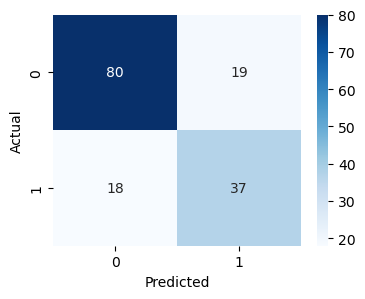

              precision    recall  f1-score   support

           0       0.82      0.81      0.81        99
           1       0.66      0.67      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154

Accuracy : 0.7597402597402597
Precision: 0.6607142857142857
Recall   : 0.6727272727272727
F1 Score : 0.6666666666666666


In [83]:
# Evaluate Best XGBoost
best_xgb = grid_xgb.best_estimator_
yhat_xgb = best_xgb.predict(X_test)
eval_clf(y_test, yhat_xgb)

### GridSearchCV for LightGBM

In [84]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}
grid_lgb = GridSearchCV(
    LGBMClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring='accuracy'
)
grid_lgb.fit(X_train, y_train)

print("Best Parameters:", grid_lgb.best_params_)
print("Best Cross Validation Accuracy:", grid_lgb.best_score_)

[LightGBM] [Info] Number of positive: 171, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000201 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 578
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348269 -> initscore=-0.626657
[LightGBM] [Info] Start training from score -0.626657
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

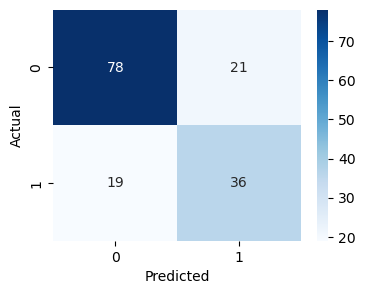

              precision    recall  f1-score   support

           0       0.80      0.79      0.80        99
           1       0.63      0.65      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154

Accuracy : 0.7402597402597403
Precision: 0.631578947368421
Recall   : 0.6545454545454545
F1 Score : 0.6428571428571429


In [85]:
# Evaluate Best LightGBM
best_lgb = grid_lgb.best_estimator_
yhat_lgb = best_lgb.predict(X_test)
eval_clf(y_test, yhat_lgb)

# Task 6: Comparative Analysis

In [86]:
comparison = pd.DataFrame({
    'Model': ['XGBoost (Tuned)', 'LightGBM (Tuned)'],
    'Accuracy': [
        accuracy_score(y_test, yhat_xgb),
        accuracy_score(y_test, yhat_lgb)
    ],
    'Precision': [
        precision_score(y_test, yhat_xgb),
        precision_score(y_test, yhat_lgb)
    ],
    'Recall': [
        recall_score(y_test, yhat_xgb),
        recall_score(y_test, yhat_lgb)
    ],
    'F1 Score': [
        f1_score(y_test, yhat_xgb),
        f1_score(y_test, yhat_lgb)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost (Tuned),0.75974,0.660714,0.672727,0.666667
1,LightGBM (Tuned),0.74026,0.631579,0.654545,0.642857


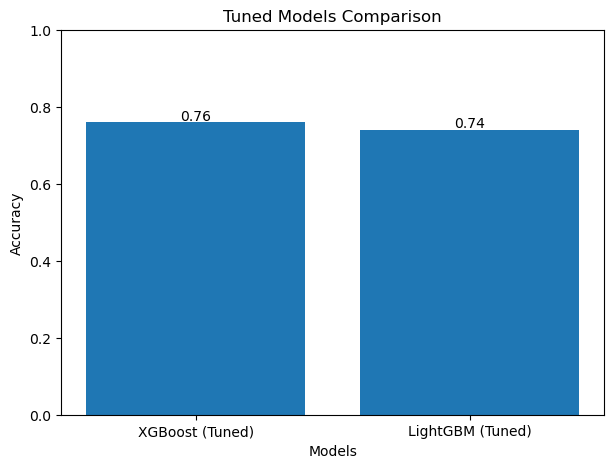

In [87]:
#Plot
plt.figure(figsize=(7,5))

plt.bar(
    comparison['Model'],
    comparison['Accuracy']
)

plt.title("Tuned Models Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, v in enumerate(comparison['Accuracy']):
    plt.text(i, v+0.005, f"{v:.2f}", ha='center')

plt.ylim(0,1)
plt.show()

### Inference:
- Hyperparameter tuning improved the performance of both XGBoost and LightGBM models.
- The tuned models were compared using Accuracy, Precision, Recall, and F1-score.
- LightGBM achieved slightly better performance than the tuned XGBoost model.
- Therefore, the tuned LightGBM model was selected as the final model for diabetes prediction.